In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.serialization

import copy
import math
import numpy as np
import glob
import os
import json
from pathlib import Path
import matplotlib.pyplot as plt
import random
from dataclasses import dataclass

In [2]:
from umap import UMAP
import hdbscan
import datamapplot

In [3]:
torch.manual_seed(1337)
random.seed(1337)

def get_device():
    device = 'cpu'
    if torch.cuda.is_available():
        torch.cuda.manual_seed(1337)
        device = 'cuda'
    print(f'using {device}')
    return torch.device(device)

torch.manual_seed(1337)
random.seed(1337)
torch.set_float32_matmul_precision('high')

DEVICE = get_device()
USE_AMP = torch.cuda.is_available()
USE_COMPILE = torch.cuda.is_available()
USE_FUSED = torch.cuda.is_available()

using cuda


In [4]:
data_dir = Path('/home/ubuntu/data/v0_6')
mask_path = data_dir / 'binary_pathway_mask.npy'
pert_dir = data_dir / 'pert_embd'
metadata_path = pert_dir / 'pert_to_id.json'
checkpoint_dir = data_dir / 'checkpoints'
gene_names_path = data_dir / 'gene_names.json'
pert_embd_path = pert_dir / 'action_embeddings_esm2.npy'

## Load Model Checkpoint

In [5]:
import sys

repo_root = Path.cwd().parents[1]  # .../biojepa/shared_notebooks -> .../(repo root)
sys.path.insert(0, str(repo_root))

from biojepa.biojepa_v0_6 import BioJepa, BioJepaConfig

In [6]:
# print('Loading Action Embedding ...')
# pert_embd = np.load(pert_embd_path)
# print(f'Bank Loaded. Shape: {pert_embd.shape}')

with open(gene_names_path, 'r') as f:
    gene_names = json.load(f)
print(f'Loaded {len(gene_names)} genes')

Loaded 10000 genes


In [7]:
model_cfg = BioJepaConfig(
    num_genes=10000,
    n_layer=6,
    heads=4,
    embed_dim=256,
    mlp_ratio=4.0,
    n_pre_layer=2,
    mask_ratio=0.766,
    gaussian_scale=2.38,
    film_linear_multiple=0.81,
    sim_coeff=40.5,
    std_coeff=40.5,
    cov_coeff=1.62,
    pert_latent_dim= 320,
    pert_mode_dim= 64,
)

model = BioJepa(model_cfg).to(DEVICE)

In [8]:
checkpoint_path = checkpoint_dir / 'biojepa_v0_6_pt_final.pt'

checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
state_dict = {k.replace('_orig_mod.', ''): v for k, v in checkpoint['model'].items()}
keys = model.load_state_dict(state_dict)

keys

<All keys matched successfully>

In [9]:
gene_embd = model.student.gene_embeddings.detach().cpu().float().numpy()
embd = gene_embd
gene_embd.shape

(10000, 256)

In [10]:
n = gene_embd.shape[0]
n

10000

In [11]:
labels = np.asarray(gene_names) 

In [12]:
model.student.linear_scaler.weight

Parameter containing:
tensor([[0.2739]], device='cuda:0', requires_grad=True)

## Load Perturbation Embeddings

In [ ]:
pert_id_file = pert_dir / 'pert_to_id.json'
pert_embd_file = pert_dir / 'action_embeddings_esm2.npy'

In [ ]:
pert_embd = np.load(pert_embd_file)
pert_embd.shape

In [ ]:
with open(pert_id_file, 'r') as f:
    pert_to_id = json.load(f)
all_perts = [i for i in pert_to_id.keys() if i != 'control']
len(all_perts)

In [ ]:
n = pert_embd.shape[0]
embd = pert_embd
n

In [ ]:
labels = np.asarray(all_perts) 

## Visualizations

In [13]:
coords = UMAP(
    n_components=2, 
    n_neighbors=30, 
    min_dist=0.5, 
    spread=2.0, 
    metric="cosine", 
    random_state=0).fit_transform(embd)

/home/ubuntu/miniconda3/envs/general/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


<InteractiveFigure width=100% height=800>
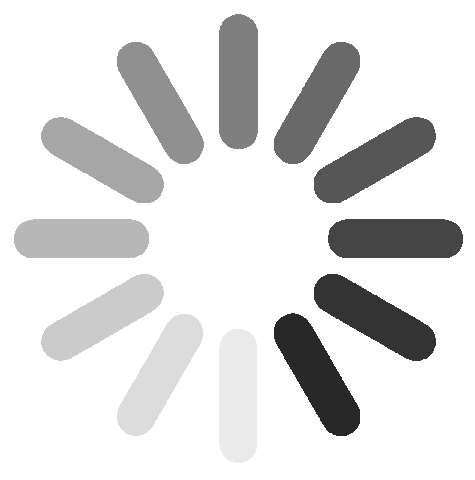

In [14]:
datamapplot.create_interactive_plot(coords, labels)

In [17]:
from sklearn.manifold import TSNE

In [18]:
coords = TSNE(
    n_components=2,
    perplexity=30,      
    learning_rate='auto',
    init='random',
    random_state=12
).fit_transform(embd)

<InteractiveFigure width=100% height=800>
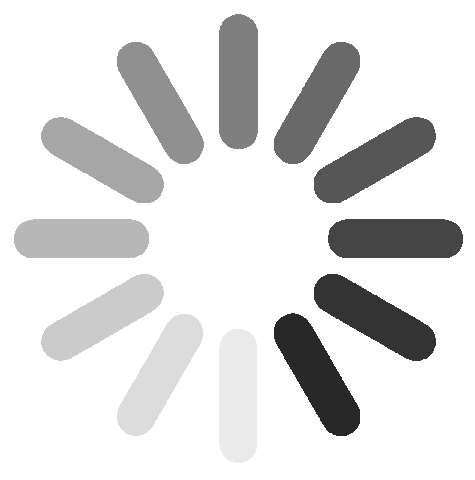

In [19]:
datamapplot.create_interactive_plot(coords, labels)

### Save coord

In [20]:
labl_to_cords = {lab: xy.tolist() for lab, xy in zip(labels, coords)}
labl_to_cords

{np.str_('LINC01409'): [-51.70085525512695, 10.161630630493164],
 np.str_('LINC01128'): [-17.696779251098633, 34.849342346191406],
 np.str_('NOC2L'): [-13.535601615905762, -55.74461364746094],
 np.str_('KLHL17'): [-0.21302366256713867, 18.305023193359375],
 np.str_('HES4'): [-3.5736172199249268, -20.926677703857422],
 np.str_('ISG15'): [5.726394176483154, 39.887351989746094],
 np.str_('SDF4'): [-33.67180633544922, -9.962985038757324],
 np.str_('B3GALT6'): [6.046493053436279, 15.631083488464355],
 np.str_('UBE2J2'): [12.981264114379883, -51.90855407714844],
 np.str_('ACAP3'): [-35.749603271484375, 19.93497085571289],
 np.str_('PUSL1'): [38.75335693359375, -29.133684158325195],
 np.str_('INTS11'): [-3.1862668991088867, -1.4636470079421997],
 np.str_('DVL1'): [11.3821439743042, -35.6678352355957],
 np.str_('MXRA8'): [-1.2595391273498535, -38.13436508178711],
 np.str_('AURKAIP1'): [39.76275634765625, 14.706538200378418],
 np.str_('CCNL2'): [-29.2957706451416, -32.01427459716797],
 np.str_(

In [21]:
with open(data_dir / 'label_to_tsne_coord.json', 'w') as f:
    json.dump(labl_to_cords, f)